In [2]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

Упражнение 3.1

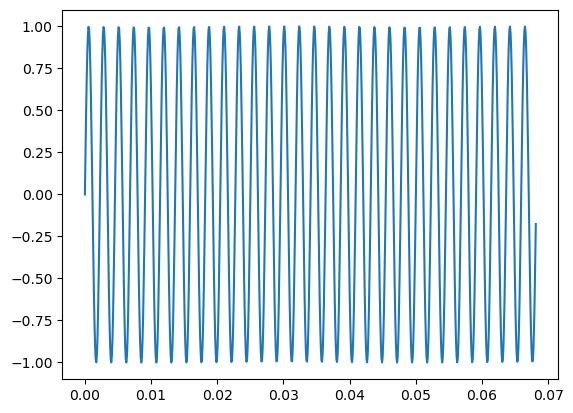

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from thinkdsp import decorate, SinSignal, ExpoChirp, Chirp

signal = SinSignal(freq=440)
duration = signal.period * 30
wave = signal.make_wave(duration)
wave.plot()

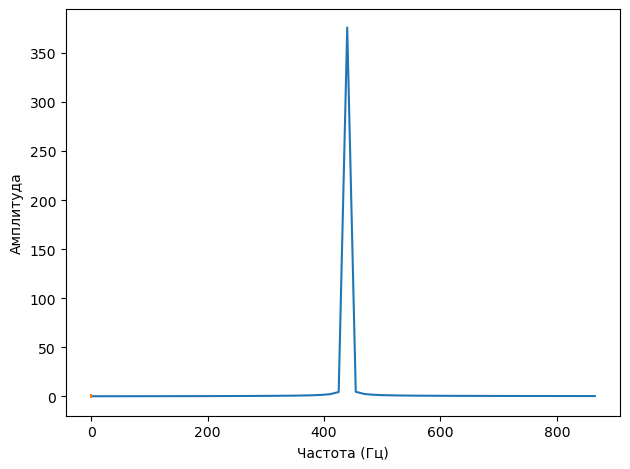

In [5]:
decorate(xlabel='Время (с)')
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')
duration = signal.period * 30.25
wave = signal.make_wave(duration)
wave.plot()

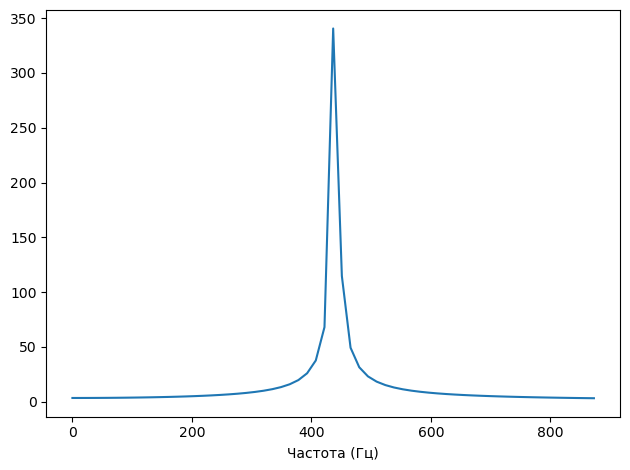

In [6]:
decorate(xlabel='Время (с)')
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Частота (Гц)')

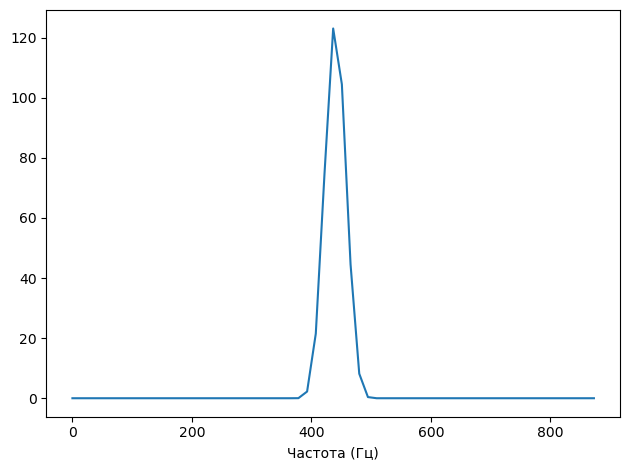

In [7]:
from numpy import kaiser
wave.ys = wave.ys * kaiser(len(wave.ys), beta=14)
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Частота (Гц)')

Упражнение 3.2

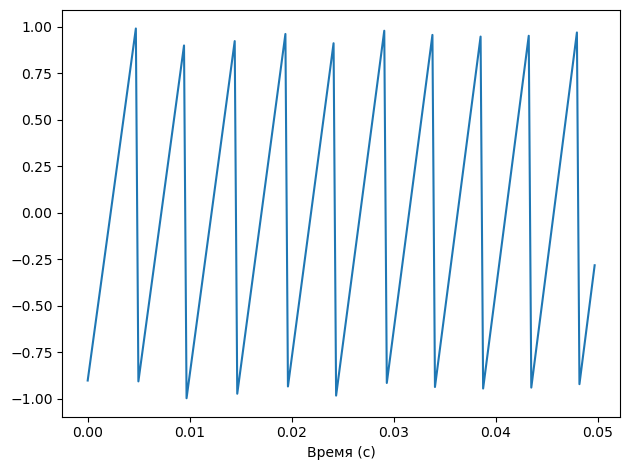

In [9]:
from thinkdsp import Chirp, normalize, unbias, PI2, decorate
import numpy as np

class SawtoothChirp(Chirp):
    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts) - 1)
        dts = np.diff(ts)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / PI2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)
        return ys

signal = SawtoothChirp(start=200, end=500)
wave = signal.make_wave(duration=1, framerate=4025)
wave.segment(start=0, duration=0.05).plot()
decorate(xlabel='Время (с)')

In [10]:
wave.apodize()
wave.make_audio()

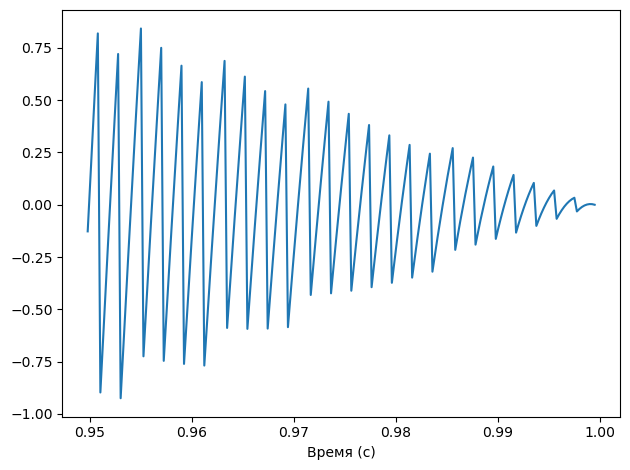

In [11]:
wave.segment(start=1-0.05, duration=0.05).plot()
decorate(xlabel='Время (с)')

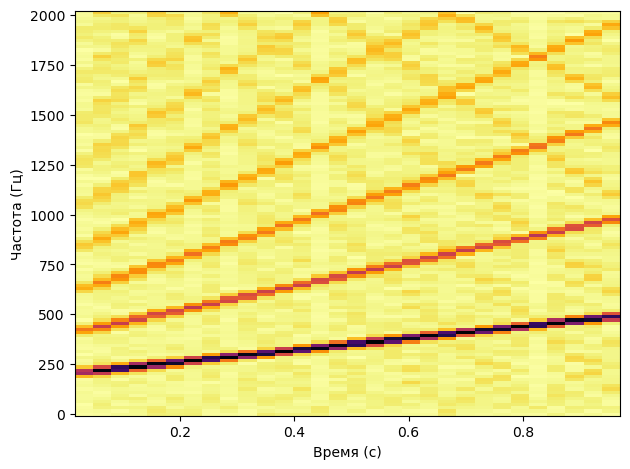

In [12]:
sp = wave.make_spectrogram(256)
sp.plot()
decorate(xlabel='Время (с)', ylabel='Частота (Гц)')

Упражнение 3.3

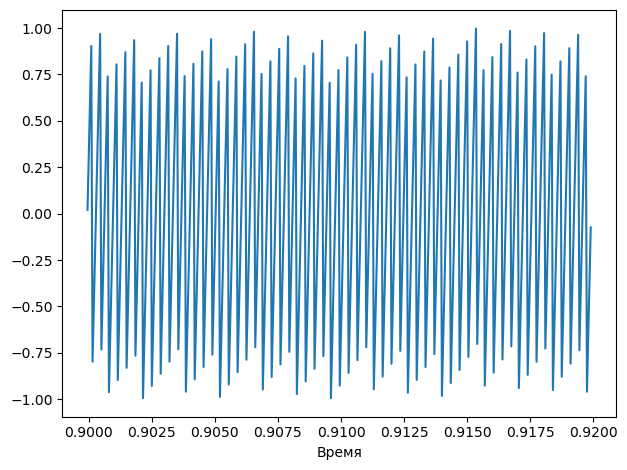

In [14]:
signal = SawtoothChirp(start=2500, end=3000)
wave = signal.make_wave(duration=1, framerate=20000)
wave.segment(start=0.9, duration=0.02).plot()
decorate(xlabel='Время')

In [15]:
wave.make_audio()

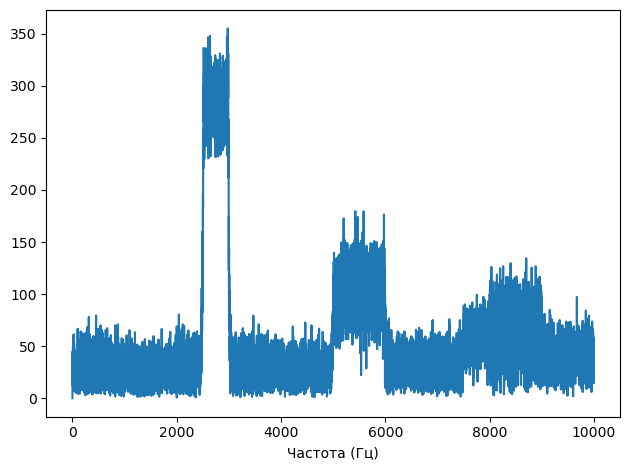

In [16]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Частота (Гц)')

Упражнение 3.4

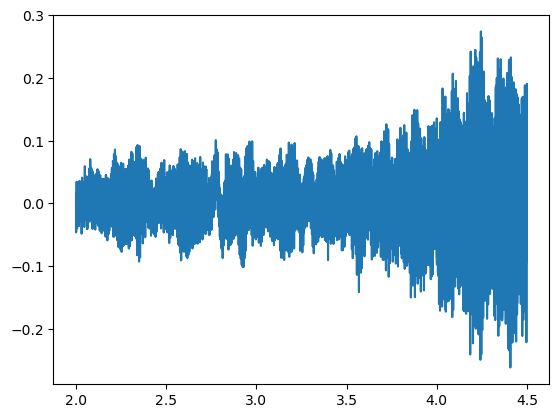

In [18]:
from thinkdsp import read_wave

wave = read_wave('glissando_exercise3.wav')
segment = wave.segment(start=2, duration=2.5)
segment.plot()

In [19]:
wave.make_audio()

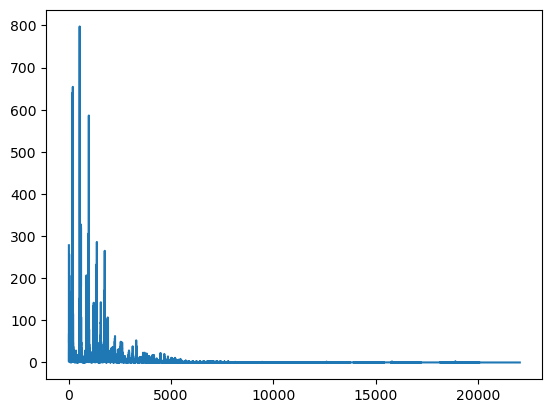

In [20]:
spectrum = segment.make_spectrum()
spectrum.plot()

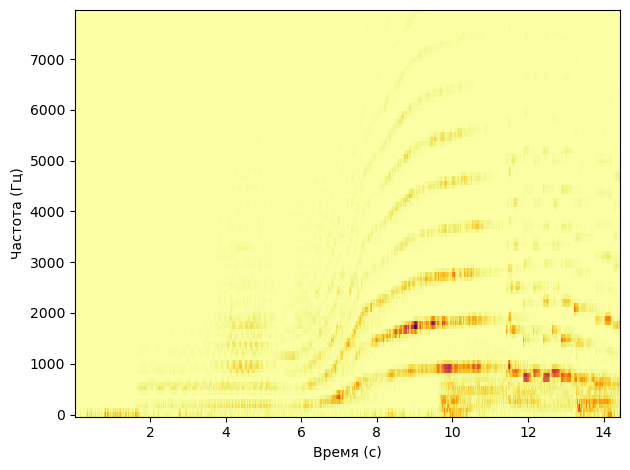

In [21]:
wave.make_spectrogram(512).plot(high=8000)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)')

Упражнение 3.5

In [23]:
class TromboneGliss(Chirp):
    def evaluate(self, ts):
        l1, l2 = 1.0 / self.start, 1.0 / self.end
        lengths = np.linspace(l1, l2, len(ts) - 1)
        freqs = 1 / lengths
        dts = np.diff(ts)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        ys = self.amp * np.cos(phases)
        return ys

signal = TromboneGliss(262, 349)
wave1 = signal.make_wave(duration=1)
wave1.apodize()
wave1.make_audio()

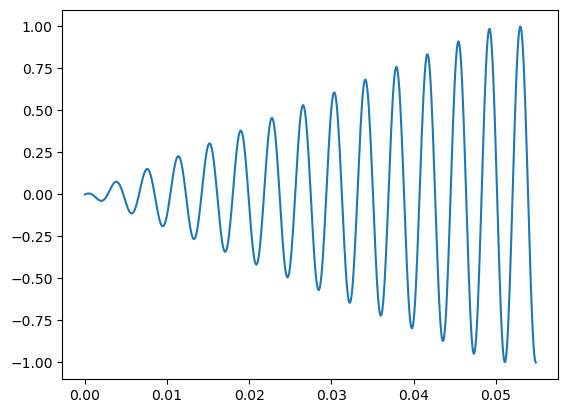

In [24]:
wave1.segment(start=0, duration=0.055).plot()

In [25]:
signal = TromboneGliss(349, 262)
wave2 = signal.make_wave(duration=1)
wave2.apodize()
wave2.make_audio()

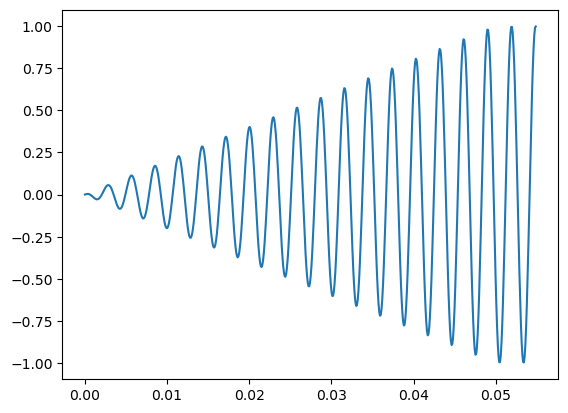

In [26]:
wave2.segment(start=0, duration=0.0550).plot()

In [27]:
wave = wave1 | wave2
wave.make_audio()

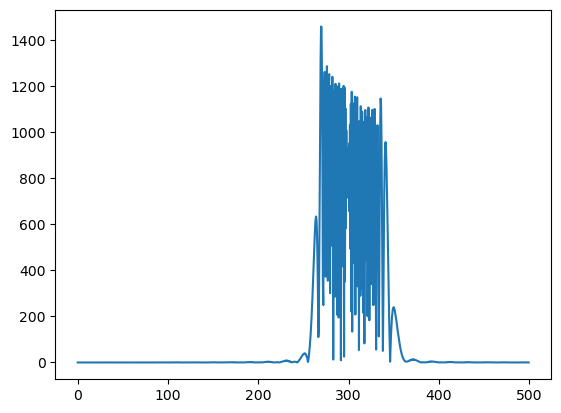

In [28]:
wave.make_spectrum().plot(high=500)

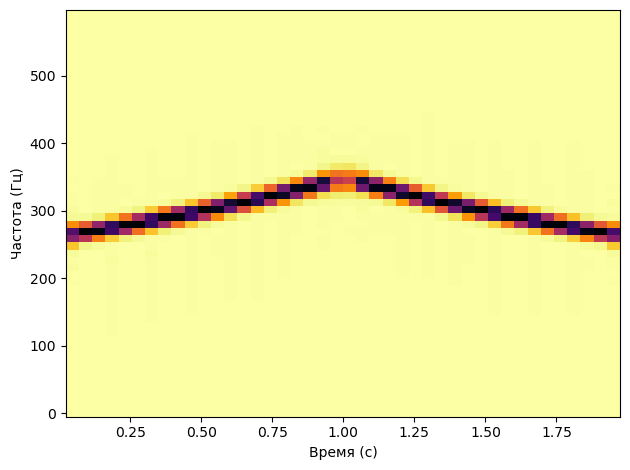

In [29]:
wave.make_spectrogram(1024).plot(high=600)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)')

Упражнение 3.6

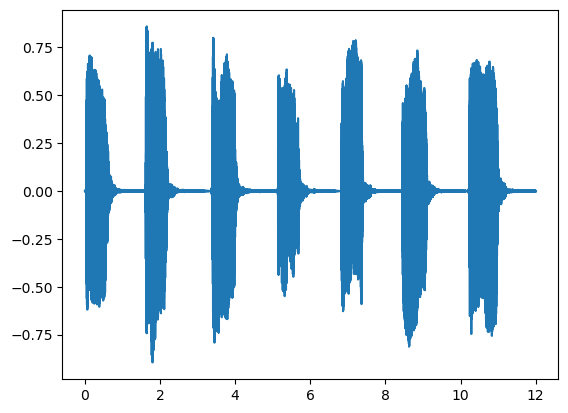

In [31]:
wave = read_wave('russian_vowels_exercise3.wav')
segment = wave.segment(start=0, duration=12)
segment.plot()

In [32]:
wave.make_audio()

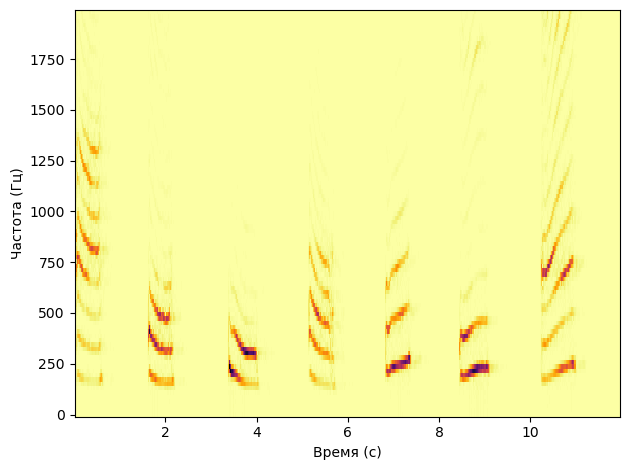

In [33]:
segment.make_spectrogram(2048).plot(high=2000)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)')